# Data_Transformation 

## Objective

Prepare the dataset for unsupervised machine learning by cleaning, transforming, and reducing the data into a format that can be used for clustering analysis.

## Goal

Create a clean and model-ready dataset that can be used in the next step of the machine learning pipeline.

In [1]:
#let's import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pickle

In [8]:
#load the dataset 
df_large = pd.read_csv('/Users/ingxrodriguez/Documents/Music_Recommendation_Algorithm/Dataset/Large_data.csv')

In [9]:
#read the first few rows of the dataset
df_large.head()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


In [10]:
#check the shape of the dataset
df.shape

(28362, 24)

In [11]:
#drop irrelevant columns

cols_to_drop = ['Unnamed: 0', 'artist_name', 'track_name', 
                'release_date', 'genre', 'topic', 'lyrics']

df_clean = df.drop(columns=cols_to_drop)
print(f"Before: 24 columns")
print(f"After:  {df_clean.shape[1]} columns")
print(f"\nRemaining columns:")
print(df_clean.columns.tolist())

Before: 24 columns
After:  17 columns

Remaining columns:
['len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'age']


In [12]:
#let's save the cleaned dataset to a new CSV file
df_clean.to_csv('/Users/ingxrodriguez/Documents/Music_Recommendation_Algorithm/Dataset/Cleaned_data.csv', index=False)

In [13]:
#check data shape
print(f"Cleaned dataset shape: {df_clean.shape}")


Cleaned dataset shape: (28362, 17)


In [14]:
df_clean.head()

,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age
0,95,0.000598,0.063746,0.000598,0.000598,0.000598,0.048857,0.017104,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,1.0
1,51,0.035537,0.096777,0.443435,0.001284,0.001284,0.027007,0.001284,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,1.0
2,24,0.002770,0.002770,0.002770,0.002770,0.002770,0.002770,0.158564,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,1.0
3,54,0.048249,0.001548,0.001548,0.001548,0.021500,0.001548,0.411536,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,1.0
4,48,0.001350,0.001350,0.417772,0.001350,0.001350,0.001350,0.463430,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,1.0


In [15]:
#check dataset info
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   len                       28362 non-null  int64  
 1   dating                    28362 non-null  float64
 2   violence                  28362 non-null  float64
 3   world/life                28362 non-null  float64
 4   night/time                28362 non-null  float64
 5   shake the audience        28362 non-null  float64
 6   family/gospel             28362 non-null  float64
 7   romantic                  28362 non-null  float64
 8   communication             28362 non-null  float64
 9   obscene                   28362 non-null  float64
 10  music                     28362 non-null  float64
 11  movement/places           28362 non-null  float64
 12  light/visual perceptions  28362 non-null  float64
 13  family/spiritual          28362 non-null  float64
 14  sadnes

In [16]:
#drop redundant features
df_clean = df_clean.drop(columns=['family/spiritual', 'feelings'], errors='ignore')
print(f"After dropping redundant features: {df_clean.shape[1]} columns")
print(f"\nFinal columns:")
print(df_clean.columns.tolist())

After dropping redundant features: 15 columns

Final columns:
['len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'sadness', 'age']


In [17]:
#check for null values
print("Null values per column:")
print(df_clean.isnull().sum())
print(f"\nTotal nulls: {df_clean.isnull().sum().sum()}")

Null values per column:
len                         0
dating                      0
violence                    0
world/life                  0
night/time                  0
shake the audience          0
family/gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement/places             0
light/visual perceptions    0
sadness                     0
age                         0
dtype: int64

Total nulls: 0


## Log Transformation of `len`

I applied log1p to `len` because in the EDA the distribution was super skewed 
to the right and messy. Hopefully with the log transformation it looks cleaner 
and works better since the model now deals with smaller, more balanced numbers 
instead of those crazy outliers pulling everything to one side.

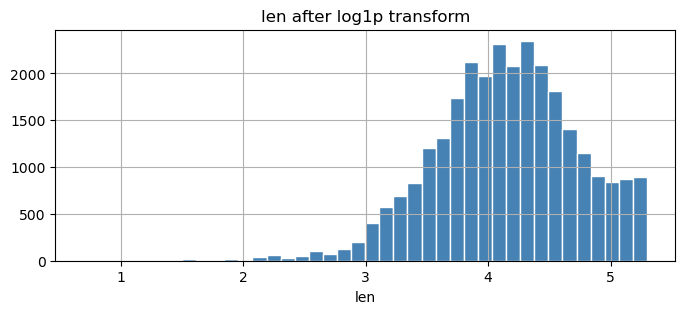

In [19]:
#cheking the len distribution again.
df_clean['len'] = np.log1p(df_clean['len'])

# Verify it worked
plt.figure(figsize=(8, 3))
df_clean['len'].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('len after log1p transform')
plt.xlabel('len')
plt.show()

In [20]:
# Now let's standardize the features to have mean ~0 and std ~1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

df_scaled = pd.DataFrame(X_scaled, columns=df_clean.columns)
print("Mean (should be ~0):")
print(df_scaled.mean().round(3))
print("\nStd (should be ~1):")
print(df_scaled.std().round(3))

Mean (should be ~0):
len                        -0.0
dating                      0.0
violence                    0.0
world/life                  0.0
night/time                  0.0
shake the audience         -0.0
family/gospel              -0.0
romantic                    0.0
communication              -0.0
obscene                     0.0
music                       0.0
movement/places             0.0
light/visual perceptions   -0.0
sadness                     0.0
age                        -0.0
dtype: float64

Std (should be ~1):
len                         1.0
dating                      1.0
violence                    1.0
world/life                  1.0
night/time                  1.0
shake the audience          1.0
family/gospel               1.0
romantic                    1.0
communication               1.0
obscene                     1.0
music                       1.0
movement/places             1.0
light/visual perceptions    1.0
sadness                     1.0
age            

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

df_scaled = pd.DataFrame(X_scaled, columns=df_clean.columns)
print("Mean (should be ~0):")
print(df_scaled.mean().round(3))
print("\nStd (should be ~1):")
print(df_scaled.std().round(3))

Mean (should be ~0):
len                        -0.0
dating                      0.0
violence                    0.0
world/life                  0.0
night/time                  0.0
shake the audience         -0.0
family/gospel              -0.0
romantic                    0.0
communication              -0.0
obscene                     0.0
music                       0.0
movement/places             0.0
light/visual perceptions   -0.0
sadness                     0.0
age                        -0.0
dtype: float64

Std (should be ~1):
len                         1.0
dating                      1.0
violence                    1.0
world/life                  1.0
night/time                  1.0
shake the audience          1.0
family/gospel               1.0
romantic                    1.0
communication               1.0
obscene                     1.0
music                       1.0
movement/places             1.0
light/visual perceptions    1.0
sadness                     1.0
age            

In [22]:
# Now let's apply PCA to reduce dimensionality while retaining 90% of the variance
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original features:    {X_scaled.shape[1]}")
print(f"After PCA components: {X_pca.shape[1]}")
print(f"Variance retained:    {pca.explained_variance_ratio_.sum():.3f}")

Original features:    15
After PCA components: 12
Variance retained:    0.905


In [23]:
#let's save PCA components to a new CSV file

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_pca.to_csv('data_preprocessed.csv', index=False)
print(f"Saved! Shape: {df_pca.shape}")

Saved! Shape: (28362, 12)


In [24]:
#let's use pickle to save the scaler, PCA model, and feature columns for later use in the recommendation algorithm
with open('scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('pca.pkl', 'wb') as f: pickle.dump(pca, f)
with open('feature_cols.pkl', 'wb') as f: pickle.dump(df_clean.columns.tolist(), f)

print("Saved scaler.pkl, pca.pkl, feature_cols.pkl")

Saved scaler.pkl, pca.pkl, feature_cols.pkl


## Summary

Starting with 24 columns, I cleaned the dataset step by step. First I dropped 
all the metadata columns that the model cannot use like artist name, track name 
and lyrics. Then I dropped `family/spiritual` and `feelings` because they were 
telling the algorithm the same thing as other features already in the dataset.

I applied log1p to `len` because it was heavily skewed and a few extremely long 
songs would have confused the model. After that I used StandardScaler so every 
feature speaks the same language and no single column dominates the clustering.

Finally I applied PCA and went from 15 features down to 12 components while 
keeping 90.5% of the original information. The dataset is now clean, balanced 
and ready for KMeans clustering.